In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random
from model import *

# Transform to tensor
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Files already downloaded and verified


/Users/yuekai/miniconda3/envs/CSSP_NN_Pruning/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.01)

epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model3(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model3(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / len(test_data)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 173.90786010026932
Total accuracy in test set: 0.6026
-------Epoch 2-------
Total loss in test set: 130.48261833190918
Total accuracy in test set: 0.7056
-------Epoch 3-------
Total loss in test set: 130.39494574069977
Total accuracy in test set: 0.7176
-------Epoch 4-------
Total loss in test set: 128.66737687587738
Total accuracy in test set: 0.7149
-------Epoch 5-------
Total loss in test set: 105.23271325230598
Total accuracy in test set: 0.7724
Number of samples misclassified by the original model: 2276


In [3]:
model3.eval()
batch_list = list(train_loader)
selected_batches = random.sample(batch_list, 8)  
X = torch.cat([batch[0] for batch in selected_batches], dim=0)
X = X.to(device)

In [7]:
import importlib
import Pruning

importlib.reload(Pruning)
pruned_model_iter = iterative_pruning(model3, X, (3,32,32), 0.6, 0.95, "RPCholesky")

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 12, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 15, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 11, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 10, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 14, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 8, layer_type: ConvBNReLU
number of out_channels: 256 -> 243

-------Begin pruning-------
layer_idx: 12, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 7, layer_type: ConvBNReLU
number of out_channels: 256 -> 243

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_chan

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 12, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 15, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 11, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 10, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 14, layer_type: ConvBNReLU
number of out_channels: 512 -> 486

-------Begin pruning-------
layer_idx: 8, layer_type: ConvBNReLU
number of out_channels: 256 -> 243

-------Begin pruning-------
layer_idx: 7, layer_type: ConvBNReLU
number of out_channels: 256 -> 243

-------Begin pruning-------
layer_idx: 12, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 16, layer_type: ConvBNReLU
number of out_chan

/Users/yuekai/Documents/CSSP_Neural_Networks_Pruning/CSSP/RPCholesky.py:27: RuntimeWarning: divide by zero encountered in divide
  F[:, i] = g / np.sqrt(g[jk])
/Users/yuekai/Documents/CSSP_Neural_Networks_Pruning/CSSP/RPCholesky.py:27: RuntimeWarning: invalid value encountered in divide
  F[:, i] = g / np.sqrt(g[jk])


-------Begin pruning-------
layer_idx: 15, layer_type: ConvBNReLU
number of out_channels: 486 -> 461

-------Begin pruning-------
layer_idx: 7, layer_type: ConvBNReLU
number of out_channels: 196 -> 186

-------Begin pruning-------
layer_idx: 19, layer_type: LinearBNReLU
number of out_neurons: 374 -> 355

-------Begin pruning-------
layer_idx: 4, layer_type: ConvBNReLU
number of out_channels: 102 -> 96

-------Begin pruning-------
layer_idx: 20, layer_type: LinearBNReLU
number of out_neurons: 230 -> 218

-------Begin pruning-------
layer_idx: 4, layer_type: ConvBNReLU
number of out_channels: 96 -> 91

-------Begin pruning-------
layer_idx: 1, layer_type: ConvBNReLU
number of out_channels: 51 -> 48

-------Begin pruning-------
layer_idx: 1, layer_type: ConvBNReLU
number of out_channels: 48 -> 45

-------Begin pruning-------
layer_idx: 7, layer_type: ConvBNReLU
number of out_channels: 186 -> 176

-------Begin pruning-------
layer_idx: 20, layer_type: LinearBNReLU
number of out_neurons: 21

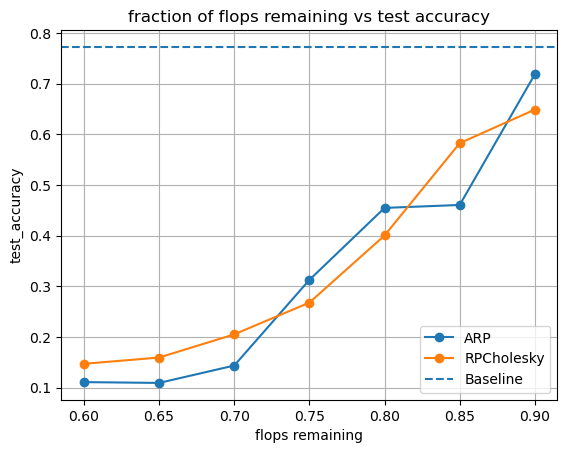

In [10]:
rho = np.linspace(0.6, 0.9, 7)
base_acc = total_accuracy / len(test_data)
methods = ["ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in rho:
        pruned_model_iter = iterative_pruning(model3, X, (3,32,32), r, 0.95, method)
        acc, _ = evaluate_pruned_model(pruned_model_iter, test_loader)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, rho, all_accs, methods,
                   title="fraction of flops remaining vs test accuracy")